<a href="https://colab.research.google.com/github/Sampavi01/Hotel_Revenue_Forecasting/blob/forecasting/LSTM_Ridge_GridSearch_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
# ================== IMPORTS ==================
import os
import itertools
from datetime import timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense

from sklearn.linear_model import Ridge
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

# ================== CONFIG / CONSTANTS ==================
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
tf.get_logger().setLevel('ERROR')

# Reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# ---- CHANGE THESE ----
INPUT_FILE_NAME = 'Model_Training_Datasets.xlsx'
CENTER_SHEET_NAME = '1'

# ---- Data & CV settings ----
TEST_SET_DAYS = 60
TARGET_RAW_COLS = ['Revenue_By_BreakFast', 'Revenue_By_Dinner', 'Revenue_By_Lunch']
LAG_DAYS = [1, 7, 14]
ROLL_WINDOWS = [7]
N_SPLITS = 2
VAL_DAYS = 90
MAPE_EPSILON = 1e-6

# ---- LSTM settings ----
N_TIMESTEPS = 7
LSTM_EPOCHS = 50
LSTM_BATCH_SIZE = 32

# ---- Grid search space (accuracy-focused, includes small & larger LRs) ----
SEARCH_SPACE_LSTM_LR = [1e-4, 5e-4, 1e-3, 5e-3]
SEARCH_SPACE_LSTM_UNITS = [32, 64, 128]
SEARCH_SPACE_RIDGE_ALPHA = [0.1, 1.0, 10.0, 100.0]

In [7]:
# ================== UTILITY FUNCTIONS ==================
def add_lag_and_rolling(df, target_cols, lag_days, roll_windows):
    df = df.copy()
    for col in target_cols:
        for lag in lag_days:
            df[f'{col}_lag{lag}'] = df[col].shift(lag)
        if pd.api.types.is_numeric_dtype(df[col]):
            for w in roll_windows:
                df[f'{col}_rollmean{w}'] = df[col].rolling(window=w, min_periods=1).mean().shift(1)
                df[f'{col}_rollstd{w}'] = df[col].rolling(window=w, min_periods=1).std().shift(1).fillna(0)
    return df.fillna(0)


def create_sequences(data, target, n_timesteps):
    X, y = [], []
    for i in range(len(data) - n_timesteps):
        X.append(data[i:(i + n_timesteps), :])
        y.append(target[i + n_timesteps])
    return np.array(X), np.array(y)


def build_lstm_hybrid_model(input_shape_lstm, lr, units):
    lstm_input = Input(shape=input_shape_lstm, name='lstm_input')
    lstm_out = LSTM(units, return_sequences=False)(lstm_input)
    dense_hidden = Dense(units // 2, activation='relu')(lstm_out)
    output = Dense(1, activation='linear', name='output')(dense_hidden)
    model = Model(inputs=lstm_input, outputs=output)
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    model.compile(optimizer=optimizer, loss='mse')
    return model


def dynamic_weights(y_true, y_pred_a, y_pred_b):
    rmse_a = np.sqrt(mean_squared_error(y_true, y_pred_a))
    rmse_b = np.sqrt(mean_squared_error(y_true, y_pred_b))
    total = rmse_a + rmse_b if (rmse_a + rmse_b) > 0 else 1.0
    w_a = 1 - (rmse_a / total)
    w_b = 1 - w_a
    return w_a, w_b


# ================== PLOTTING FUNCTIONS ==================
def plot_test_results(test_df, center_name, meal_period):
    plt.figure(figsize=(12, 6))
    plt.plot(test_df['Date'], test_df['Actual_Revenue'], label='Actual Revenue', marker='o', linestyle='-')
    plt.plot(test_df['Date'], test_df['Predicted_Revenue'], label='Predicted Revenue', marker='x', linestyle='--')
    plt.title(f'Actual vs. Predicted Revenue (Test) - {center_name} - {meal_period}')
    plt.xlabel('Date'); plt.ylabel('Revenue'); plt.legend()
    plt.grid(True, alpha=0.5); plt.xticks(rotation=45); plt.tight_layout(); plt.show()


def plot_residuals_over_time(residuals_df, center_name, meal_period):
    residuals_df = residuals_df.copy()
    residuals_df['Residual'] = residuals_df['Actual_Revenue'] - residuals_df['Predicted_Revenue']
    plt.figure(figsize=(12, 5))
    plt.plot(residuals_df['Date'], residuals_df['Residual'], marker='.', linestyle='None', alpha=0.6)
    plt.axhline(0, color='red', linestyle='--', linewidth=1)
    plt.title(f'Test Residuals Over Time - {center_name} - {meal_period}')
    plt.xlabel('Date'); plt.ylabel('Residual (Actual - Predicted)')
    plt.grid(True, alpha=0.5); plt.xticks(rotation=45); plt.tight_layout(); plt.show()

In [8]:
# ================== CV SCORING WITH VALIDATION-DERIVED ENSEMBLE WEIGHTS ==================
def score_ensemble_lstm_and_weights(params, X_train_full, Y_train_full, tscv,
                                    raw_target_col, numeric_features, categorical_features):
    """
    Returns:
      - avg_rmse across folds
      - avg_w_lstm across folds
      - avg_w_ridge across folds
    Ensemble weights are computed per fold on the validation set, then averaged across folds.
    """
    lr, units, alpha = params
    fold_rmses = []
    fold_w_lstm = []
    fold_w_ridge = []

    for train_idx, val_idx in tscv.split(X_train_full):
        # Split data
        X_train_cv_raw, X_val_raw = X_train_full.iloc[train_idx], X_train_full.iloc[val_idx]
        Y_train_cv = Y_train_full.iloc[train_idx][raw_target_col]
        Y_val = Y_train_full.iloc[val_idx][raw_target_col]

        # Fit scaler on TRAIN only; transform VAL (no leakage)
        scaler = StandardScaler()
        X_train_num_scaled = scaler.fit_transform(X_train_cv_raw[numeric_features])
        X_val_num_scaled = scaler.transform(X_val_raw[numeric_features])

        # Combine scaled numeric + categorical
        X_train_cv_scaled = pd.concat(
            [pd.DataFrame(X_train_num_scaled, columns=numeric_features, index=X_train_cv_raw.index),
             X_train_cv_raw[categorical_features]],
            axis=1
        )
        X_val_scaled = pd.concat(
            [pd.DataFrame(X_val_num_scaled, columns=numeric_features, index=X_val_raw.index),
             X_val_raw[categorical_features]],
            axis=1
        )

        # Sequence creation (per fold)
        X_seq_train, Y_seq_train = create_sequences(X_train_cv_scaled.values, Y_train_cv.values, N_TIMESTEPS)
        X_seq_val, Y_seq_val = create_sequences(X_val_scaled.values, Y_val.values, N_TIMESTEPS)

        if len(X_seq_train) == 0 or len(X_seq_val) == 0:
            continue

        # Ridge data aligned with sequences
        X_ridge_train = X_train_cv_scaled.iloc[N_TIMESTEPS:]
        X_ridge_val = X_val_scaled.iloc[N_TIMESTEPS:]
        Y_ridge_train = Y_train_cv.iloc[N_TIMESTEPS:]

        # Build & train LSTM per fold
        tf.keras.backend.clear_session()
        lstm_model = build_lstm_hybrid_model(
            input_shape_lstm=(N_TIMESTEPS, X_seq_train.shape[2]),
            lr=lr,
            units=units
        )
        es_callback = tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=10, restore_best_weights=True
        )
        lstm_model.fit(
            X_seq_train, Y_seq_train,
            validation_data=(X_seq_val, Y_seq_val),
            epochs=LSTM_EPOCHS,
            batch_size=LSTM_BATCH_SIZE,
            callbacks=[es_callback],
            verbose=0
        )
        y_pred_lstm = lstm_model.predict(X_seq_val, verbose=0).flatten()

        # Train Ridge per fold
        ridge_model = Ridge(alpha=alpha).fit(X_ridge_train, Y_ridge_train)
        y_pred_ridge = ridge_model.predict(X_ridge_val).flatten()

        # Align lengths
        min_len = min(len(Y_seq_val), len(y_pred_lstm), len(y_pred_ridge))
        if min_len == 0:
            continue
        Y_seq_val_trunc = Y_seq_val[:min_len]
        y_pred_lstm_trunc = y_pred_lstm[:min_len]
        y_pred_ridge_trunc = y_pred_ridge[:min_len]

        # Compute fold weights on VAL only (no leakage) and ensemble
        w_lstm, w_ridge = dynamic_weights(Y_seq_val_trunc, y_pred_lstm_trunc, y_pred_ridge_trunc)
        y_pred_val_ens = (w_lstm * y_pred_lstm_trunc) + (w_ridge * y_pred_ridge_trunc)

        rmse = np.sqrt(mean_squared_error(Y_seq_val_trunc, y_pred_val_ens))
        fold_rmses.append(rmse)
        fold_w_lstm.append(w_lstm)
        fold_w_ridge.append(w_ridge)

    avg_rmse = np.mean(fold_rmses) if fold_rmses else float('inf')
    avg_w_lstm = float(np.mean(fold_w_lstm)) if fold_w_lstm else 0.5
    avg_w_ridge = float(np.mean(fold_w_ridge)) if fold_w_ridge else 0.5
    return avg_rmse, avg_w_lstm, avg_w_ridge

In [9]:
# ================== MAIN TRAINING FUNCTION FOR CENTER 1 ==================
def train_and_plot_for_center(df_center, center_name):
    # 1. Feature engineering
    df_center = add_lag_and_rolling(df_center, TARGET_RAW_COLS, LAG_DAYS, ROLL_WINDOWS)
    df_center = df_center.sort_values('Date').reset_index(drop=True)

    max_date = df_center['Date'].max()
    test_start_date = max_date - timedelta(days=TEST_SET_DAYS)

    df_train_full = df_center[df_center['Date'] < test_start_date].copy().dropna()
    df_test_full = df_center[df_center['Date'] >= test_start_date].copy()

    if df_train_full.empty or df_test_full.empty:
        print(f"Skipping center {center_name}: Training or Test set is empty after feature engineering/lagging.")
        return

    # CV setup (use gap if needed to guarantee enough timesteps)
    tscv = TimeSeriesSplit(n_splits=N_SPLITS, test_size=VAL_DAYS)

    feature_cols = [c for c in df_train_full.columns if c not in ['Date'] + TARGET_RAW_COLS]
    numeric_features = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df_train_full[c])]
    categorical_features = [c for c in feature_cols if c not in numeric_features]

    X_train_full = df_train_full[feature_cols]
    Y_train_full = df_train_full[TARGET_RAW_COLS]

    gs_combinations = list(itertools.product(
        SEARCH_SPACE_LSTM_LR,
        SEARCH_SPACE_LSTM_UNITS,
        SEARCH_SPACE_RIDGE_ALPHA
    ))

    # Train each meal period separately
    for raw_target_col in TARGET_RAW_COLS:
        meal_period = raw_target_col.replace('Revenue_By_', '')

        best_rmse = float('inf')
        best_params = None
        best_weights = (0.5, 0.5)  # default fallback

        print(f"\n⚙️ Grid Search for {center_name} - {meal_period}: {len(gs_combinations)} combos")

        # ---- Grid Search: pick best params by CV RMSE, also collect avg ensemble weights from CV folds ----
        for params in gs_combinations:
            avg_rmse, avg_w_lstm, avg_w_ridge = score_ensemble_lstm_and_weights(
                params=params,
                X_train_full=X_train_full,
                Y_train_full=Y_train_full,
                tscv=tscv,
                raw_target_col=raw_target_col,
                numeric_features=numeric_features,
                categorical_features=categorical_features
            )
            if avg_rmse < best_rmse:
                best_rmse = avg_rmse
                best_params = params
                best_weights = (avg_w_lstm, avg_w_ridge)

        best_lr, best_units, best_alpha = best_params
        w_lstm_cv, w_ridge_cv = best_weights

        print(f"✅ Best Params for {center_name} - {meal_period}: "
              f"LR={best_lr:.5f}, Units={best_units}, Alpha={best_alpha:.2f}, Avg CV RMSE={best_rmse:.2f}")
        print(f"✅ Ensemble weights (from CV, no leakage): LSTM={w_lstm_cv:.3f}, Ridge={w_ridge_cv:.3f}")

        # ---- Final training with best params on full training set ----
        final_scaler = StandardScaler()
        X_train_full_scaled = pd.DataFrame(
            final_scaler.fit_transform(X_train_full[numeric_features]),
            columns=numeric_features,
            index=X_train_full.index
        )
        X_train_final = pd.concat([X_train_full_scaled, df_train_full[categorical_features]], axis=1)

        # LSTM train data
        Y_train_target = Y_train_full[raw_target_col].values
        X_seq_train_final, Y_seq_train_final = create_sequences(X_train_final.values, Y_train_target, N_TIMESTEPS)
        if len(X_seq_train_final) == 0:
            print(f"Not enough data for LSTM sequences in {center_name} - {meal_period}. Skipping.")
            continue

        # Ridge train data
        X_ridge_train_final = X_train_final.iloc[N_TIMESTEPS:]
        Y_ridge_train_final = Y_train_full[raw_target_col].iloc[N_TIMESTEPS:]

        # Train final LSTM
        tf.keras.backend.clear_session()
        final_lstm_model = build_lstm_hybrid_model(
            input_shape_lstm=(N_TIMESTEPS, X_seq_train_final.shape[2]),
            lr=best_lr,
            units=best_units
        )
        es_callback = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=5, restore_best_weights=True)
        final_lstm_model.fit(
            X_seq_train_final, Y_seq_train_final,
            epochs=min(LSTM_EPOCHS, 50),
            batch_size=LSTM_BATCH_SIZE,
            callbacks=[es_callback],
            verbose=0
        )

        # Train final Ridge
        final_ridge_model = Ridge(alpha=best_alpha).fit(X_ridge_train_final, Y_ridge_train_final)

        # ---- Prepare test data (transform with train-only scaler, no leakage) ----
        X_test_scaled = pd.DataFrame(
            final_scaler.transform(df_test_full[numeric_features]),
            columns=numeric_features,
            index=df_test_full.index
        )
        X_test_final = pd.concat([X_test_scaled, df_test_full[categorical_features]], axis=1).fillna(0)
        Y_test_raw = df_test_full[raw_target_col].values

        # Continuous LSTM input: tail of train + test
        X_full_for_test = pd.concat([X_train_final.tail(N_TIMESTEPS), X_test_final], ignore_index=True).values
        X_seq_test, _ = create_sequences(X_full_for_test, np.zeros_like(X_full_for_test[:, 0]), N_TIMESTEPS)

        # Predictions
        y_test_lstm = final_lstm_model.predict(X_seq_test, verbose=0).flatten()
        y_test_ridge = final_ridge_model.predict(X_test_final).flatten()

        # Align lengths
        min_len_test = min(len(Y_test_raw), len(y_test_lstm), len(y_test_ridge))
        if min_len_test <= 0:
            print(f"Skipping final prediction for {center_name} - {meal_period}: Test data too short.")
            continue

        Y_test_raw_trunc = Y_test_raw[:min_len_test]
        y_test_lstm_trunc = y_test_lstm[:min_len_test]
        y_test_ridge_trunc = y_test_ridge[:min_len_test]

        # ---- Final ensemble using CV-derived weights (no test leakage) ----
        y_test_ens = (w_lstm_cv * y_test_lstm_trunc) + (w_ridge_cv * y_test_ridge_trunc)

        test_rmse = np.sqrt(mean_squared_error(Y_test_raw_trunc, y_test_ens))
        test_mape = np.mean(np.abs(Y_test_raw_trunc - y_test_ens) / np.maximum(Y_test_raw_trunc, MAPE_EPSILON)) * 100

        print(f"\n--- FINAL TEST RESULTS ({center_name} - {meal_period}) ---")
        print(f"TEST RMSE: {test_rmse:.2f}, TEST MAPE: {test_mape:.2f}%")

        # Plots
        plot_df = pd.DataFrame({
            'Date': df_test_full['Date'].iloc[:min_len_test],
            'Actual_Revenue': Y_test_raw_trunc,
            'Predicted_Revenue': y_test_ens
        })
        plot_test_results(plot_df, center_name, meal_period)
        plot_residuals_over_time(plot_df, center_name, meal_period)


⚙️ Grid Search for 1 - BreakFast: 48 combos
✅ Best Params for 1 - BreakFast: LR=0.00500, Units=128, Alpha=1.00, Avg CV RMSE=905.03
✅ Ensemble weights (from CV, no leakage): LSTM=0.441, Ridge=0.559

--- FINAL TEST RESULTS (1 - BreakFast) ---
TEST RMSE: 994.28, TEST MAPE: 2770408567.58%


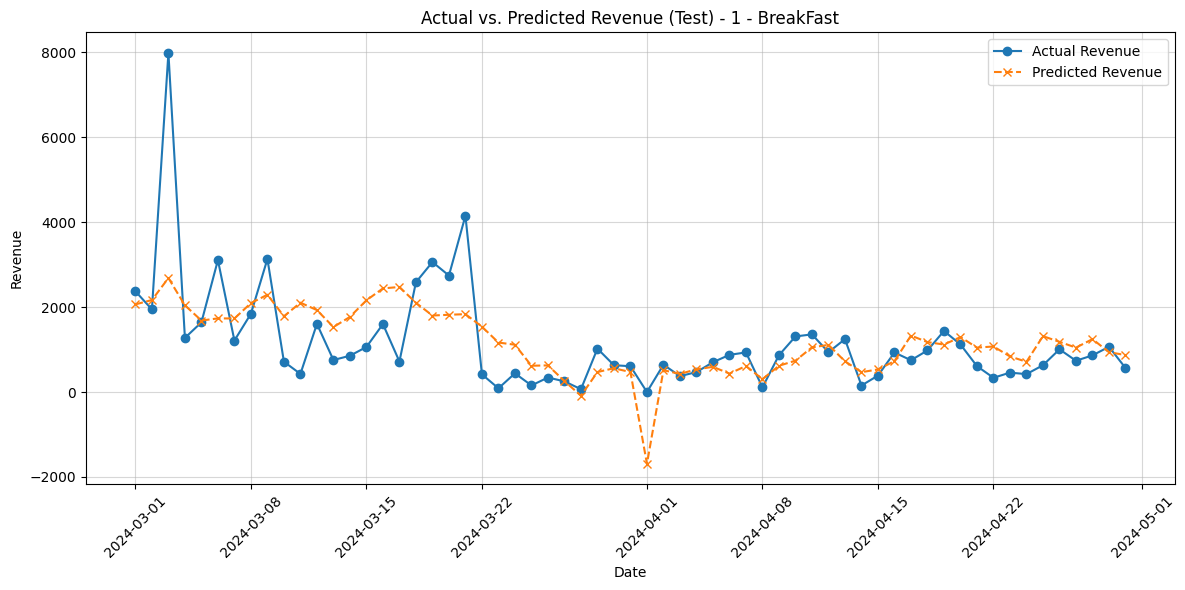

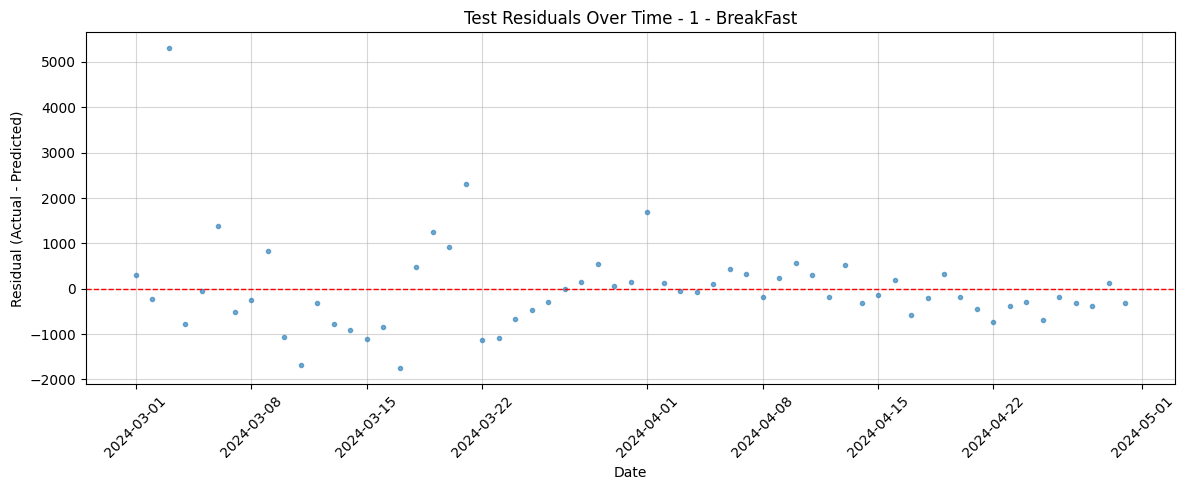


⚙️ Grid Search for 1 - Dinner: 48 combos
✅ Best Params for 1 - Dinner: LR=0.00500, Units=128, Alpha=0.10, Avg CV RMSE=1058.36
✅ Ensemble weights (from CV, no leakage): LSTM=0.263, Ridge=0.737

--- FINAL TEST RESULTS (1 - Dinner) ---
TEST RMSE: 812.92, TEST MAPE: 29.12%


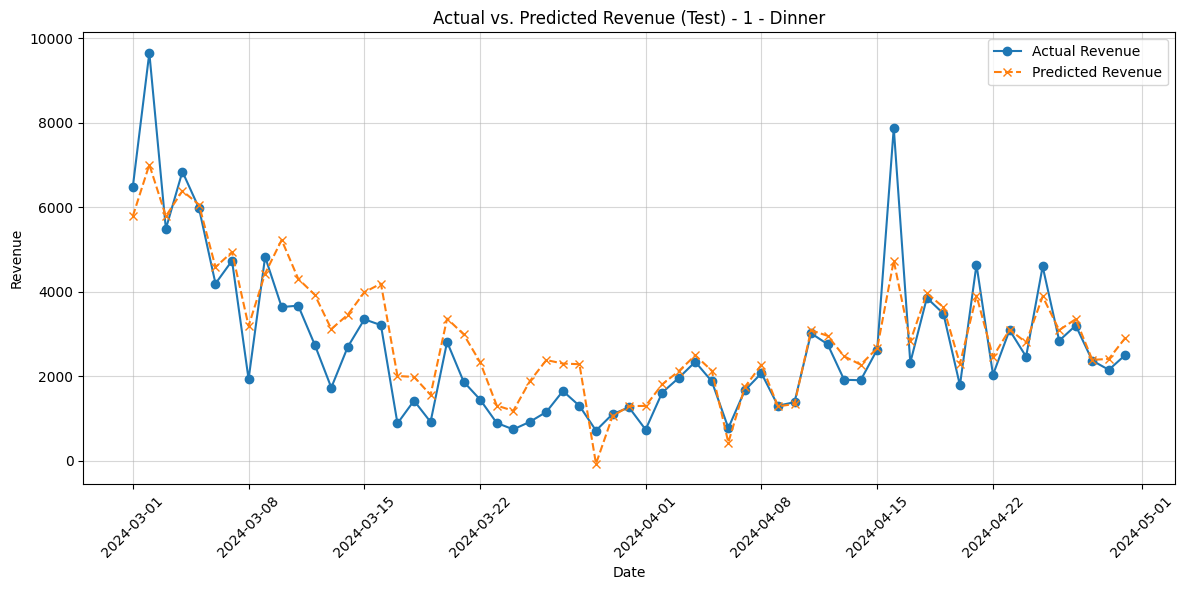

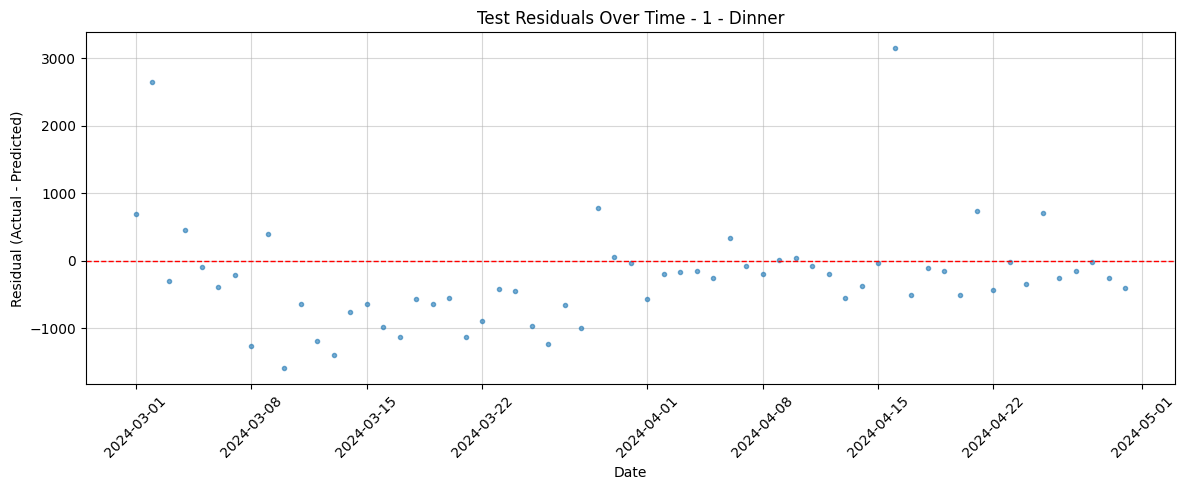


⚙️ Grid Search for 1 - Lunch: 48 combos
✅ Best Params for 1 - Lunch: LR=0.00500, Units=128, Alpha=0.10, Avg CV RMSE=775.98
✅ Ensemble weights (from CV, no leakage): LSTM=0.469, Ridge=0.531

--- FINAL TEST RESULTS (1 - Lunch) ---
TEST RMSE: 647.73, TEST MAPE: 1763810860.25%


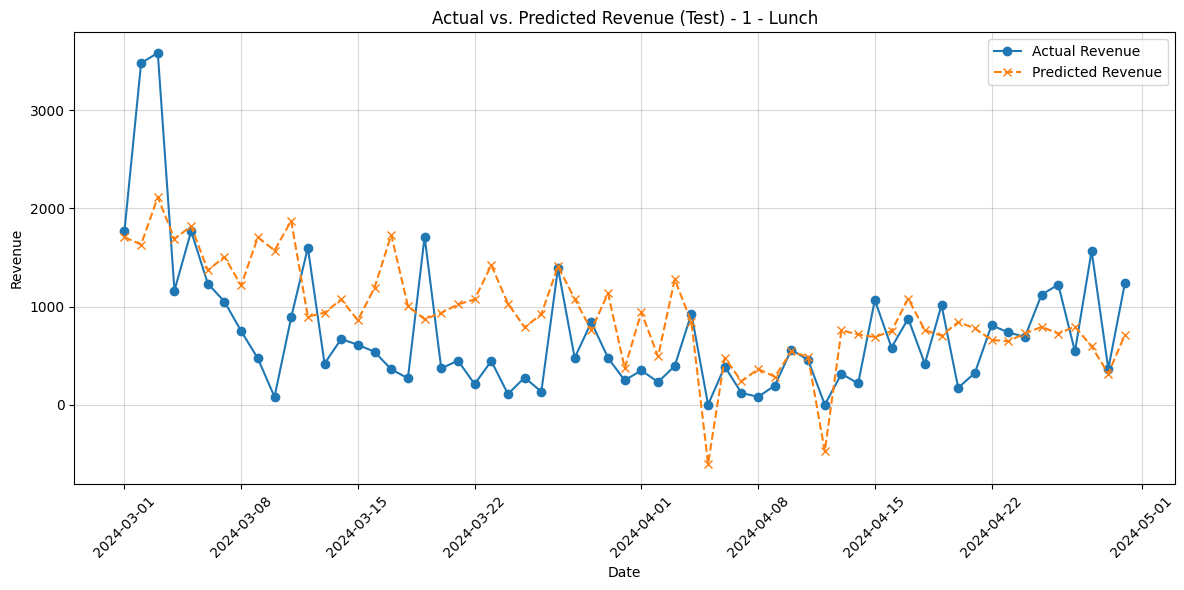

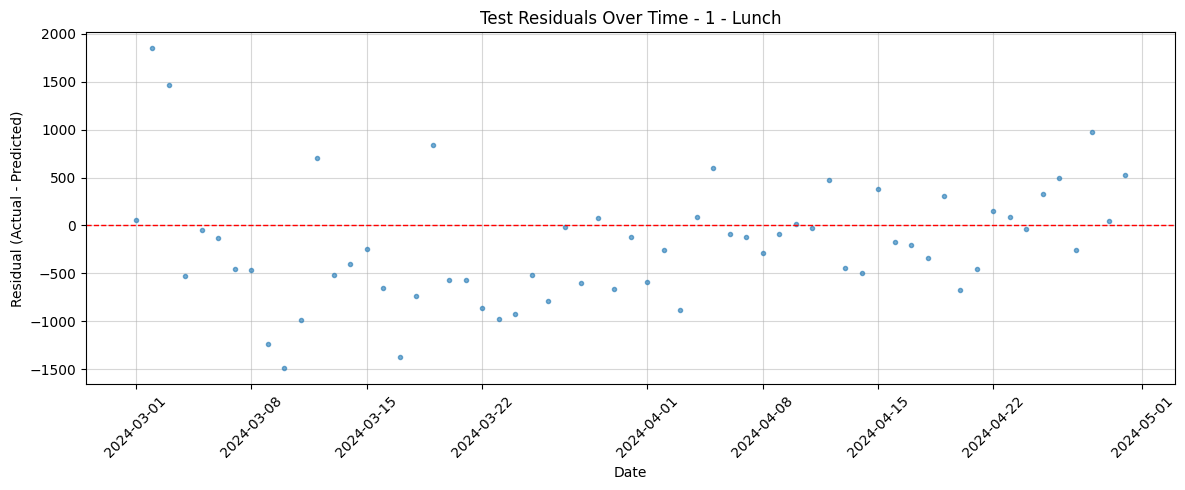

In [10]:
# ================== LOAD CENTER 1 AND RUN ==================
def load_center_from_excel(file_path, center_sheet_name):
    df = pd.read_excel(file_path, sheet_name=center_sheet_name)
    if 'Date' in df.columns:
        df['Date'] = pd.to_datetime(df['Date'])
    else:
        raise ValueError("Expected a 'Date' column in the sheet.")
    return df


if __name__ == '__main__':
    df_center_1 = load_center_from_excel(INPUT_FILE_NAME, CENTER_SHEET_NAME)
    # Use a friendly display name for plots even if sheet name is numeric
    display_name = "Revenue Centre 1" if CENTER_SHEET_NAME == 1 else str(CENTER_SHEET_NAME)
    train_and_plot_for_center(df_center_1, display_name)